In [43]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [14]:
# Length of data
N = 100

In [15]:
data = np.arange(1,N+1)
data

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [16]:
err = np.random.uniform(size=N)
err

array([0.70877874, 0.18147257, 0.75008668, 0.99776725, 0.62106796,
       0.67183943, 0.11973294, 0.09191089, 0.56339192, 0.48273048,
       0.14163562, 0.85769543, 0.08395056, 0.30492512, 0.58575232,
       0.61078524, 0.7807914 , 0.85667663, 0.84593445, 0.1249672 ,
       0.21544998, 0.61093303, 0.57306252, 0.34660046, 0.11522617,
       0.88488487, 0.85492727, 0.60627179, 0.59509637, 0.19250452,
       0.09453372, 0.86577258, 0.84689389, 0.19609023, 0.52154186,
       0.24479828, 0.69256237, 0.18103093, 0.58343357, 0.13030961,
       0.04284211, 0.37969794, 0.20372564, 0.52722815, 0.92335676,
       0.51050642, 0.49009218, 0.24630161, 0.083004  , 0.85647058,
       0.53685283, 0.57783442, 0.8339841 , 0.347695  , 0.03233586,
       0.09152379, 0.07993214, 0.454962  , 0.00659259, 0.61299664,
       0.19048352, 0.19664663, 0.70644622, 0.49768745, 0.98122652,
       0.90274281, 0.15664669, 0.00277907, 0.96025478, 0.35017037,
       0.68897274, 0.68342252, 0.63738853, 0.50278025, 0.95124

In [17]:
# Total weighted mean
np.average(data,weights=err)

50.794361213470765

In [18]:
p = np.arange(3,1+round(N//3),1)
p

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33])

In [21]:
weights = 1/(err**2)
normalized_weights = weights / weights.sum()

In [77]:
for k in range(len(p)): 
        # Sliding windows 
        left = 0 
        right = p[k]
        ybar = []
        ybar_weighted = []
        ybar_weighted_norm = []
        ybar_WMA = []
        ybar_WMA_norm = []
        ybar_conv_same = []
        ybar_conv_val = []
        ybar_conv_same_norm = []
        ybar_conv_val_norm = []
        
        ybar_conv_same = np.convolve(data,weights,'same')
        ybar_conv_valid= np.convolve(data,weights,'valid')
        ybar_conv_same_norm = np.convolve(data,normalized_weights,'same')
        ybar_conv_val_norm = np.convolve(data,normalized_weights,'valid')
        
        while right <= N:
            # usual mean
            ybar.append(np.mean(data[left:right]))
            
            # manual
            ybar_WMA.append((weights[left:right]*data[left:right]).sum()/weights.sum())
            ybar_WMA_norm.append((normalized_weights[left:right]*data[left:right]).sum()/normalized_weights.sum())
            
            # np avg
            ybar_weighted.append(np.average(data[left:right], weights=weights[left:right]))
            ybar_weighted_norm.append(np.average(data[left:right], weights=normalized_weights[left:right]))
            left += 1 
            right += 1       

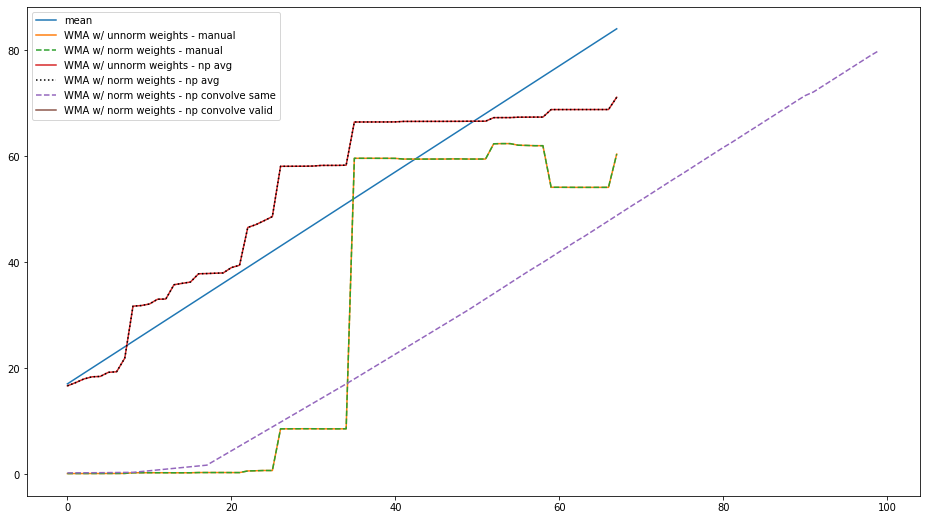

In [81]:
plt.figure(figsize=(16,9))
plt.plot(ybar,label='mean')
plt.plot(ybar_WMA, label='WMA w/ unnorm weights - manual')
plt.plot(ybar_WMA_norm, label='WMA w/ norm weights - manual',linestyle='dashed')
plt.plot(ybar_weighted, label='WMA w/ unnorm weights - np avg')
plt.plot(ybar_weighted_norm, label='WMA w/ norm weights - np avg',linestyle='dotted',color='black')
plt.plot(ybar_conv_same_norm, label='WMA w/ norm weights - np convolve same',linestyle='dashed')
plt.plot(ybar_conv_val_norm, label='WMA w/ norm weights - np convolve valid')
plt.legend()

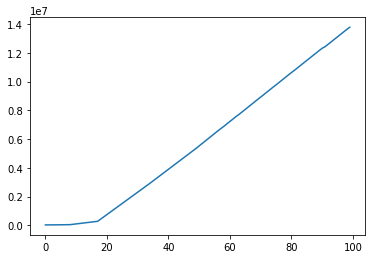

In [83]:
plt.plot(ybar_conv_same, label='WMA w/ unnorm weights - np convolve same')
plt.plot(ybar_conv_val, label='WMA w/ unnorm weights - np convolve valid')

In [64]:
ybar_WMA

[0.07461416175755428,
 0.07972884446318317,
 0.08012273476549528,
 0.0835745243567619,
 0.08399844401651055,
 0.09064545012713686,
 0.091232606746652,
 0.10205830055929911,
 0.2260689711525555,
 0.22759348758053274,
 0.23335101200933994,
 0.23108977131521197,
 0.23130119070050656,
 0.2216307847582992,
 0.22189228662971003,
 0.22622592529206983,
 0.26720873114707533,
 0.26744223100068487,
 0.26832590587932154,
 0.26907485408664783,
 0.2620920981544345,
 0.26205891664049324,
 0.5666641563603565,
 0.6050151598593365,
 0.6555774245852518,
 0.6462857633523207,
 8.51601067643916,
 8.516722207607414,
 8.526027011331,
 8.534847268698014,
 8.530885894271282,
 8.51227353757264,
 8.512417424941402,
 8.512620197621805,
 8.523323317192068,
 59.56611223177439,
 59.563063347120774,
 59.5659256901895,
 59.560070666340586,
 59.56030013075537,
 59.54768539382026,
 59.419881637983664,
 59.41867325180826,
 59.41325529136114,
 59.41762288288552,
 59.42034829339164,
 59.42230102119136,
 59.44929383128976,
 

In [ ]:
df = pd.DataFrame({'Data':data, 'Error':err, 'Weights': normalized_weights})
df